# Trabalho 05 — Amplificação de Brilho
## Ganho multiplicativo de 20% sobre imagem PGM de 5 bits

**Disciplina:** Computação Gráfica / Processamento de Imagens Digitais
**Professor:** André Alessandro Stein
**Aluno:** Igor
**Instituição:** IFC — Campus Rio do Sul

### Enunciado

> Aplicar ganho de 20% de claridade (`ganhobrilho = valorpixel * 1,2`) à imagem
> gerada na "Atividade 4".

### Entrada

O arquivo `SaidaEscalaCinza_5bits.pgm`, produzido na Atividade 4: PGM tipo P2,
800 × 800, **`maxval = 31`** (5 bits de profundidade).

### O problema central

A imagem de entrada tem teto em 31. Multiplicando o valor máximo presente por
1,2 chega-se a valores **acima desse teto** — que não podem ser representados.
Ignorar isso produziria um arquivo PGM inválido.

Este notebook trata a questão explicitamente: quantifica quantos píxeis
estouram, aplica **saturação** (*clipping*), e discute o que se perde no
processo.

### Referências

- STEIN, A. A.; HECK, C. *Processamento de Imagens Digitais* — slides da disciplina.
- LOPES, J. M. Brisson. *Formatos de Imagem*. DEI — IST, Lisboa, 2003 (reed. 2013).

# Trabalho 05 — Amplificação de Brilho
## Ganho multiplicativo de 20% sobre imagem PGM de 5 bits

**Disciplina:** Computação Gráfica / Processamento de Imagens Digitais
**Professor:** André Alessandro Stein
**Aluno:** Igor
**Instituição:** IFC — Campus Rio do Sul

### Enunciado

> Aplicar ganho de 20% de claridade (`ganhobrilho = valorpixel * 1,2`) à imagem
> gerada na "Atividade 4".

### Entrada

O arquivo `SaidaEscalaCinza_5bits.pgm`, produzido na Atividade 4: PGM tipo P2,
800 × 800, **`maxval = 31`** (5 bits de profundidade).

### O problema central

A imagem de entrada tem teto em 31. Multiplicando o valor máximo presente por
1,2 chega-se a valores **acima desse teto** — que não podem ser representados.
Ignorar isso produziria um arquivo PGM inválido.

Este notebook trata a questão explicitamente: quantifica quantos píxeis
estouram, aplica **saturação** (*clipping*), e discute o que se perde no
processo.

### Referências

- STEIN, A. A.; HECK, C. *Processamento de Imagens Digitais* — slides da disciplina.
- LOPES, J. M. Brisson. *Formatos de Imagem*. DEI — IST, Lisboa, 2003 (reed. 2013).

## 1. Fundamentação

### Transformações pontuais

O ajuste de brilho pertence à classe das **transformações pontuais**: o novo
valor de cada píxel depende **apenas** do valor antigo daquele mesmo píxel,
sem qualquer influência da vizinhança. Formalmente:

    g(x, y) = T[ f(x, y) ]

Essa propriedade tem duas consequências práticas úteis:

- A operação é **totalmente vetorizável** — não há laços sobre píxeis.
- A transformação pode ser resumida em uma **tabela de mapeamento** (LUT) com
  apenas 32 entradas, uma por nível possível. Conhecer a tabela é conhecer
  integralmente o efeito sobre qualquer imagem de 5 bits.

### Ganho multiplicativo × deslocamento aditivo

Há duas formas distintas de "clarear" uma imagem:

| Operação      | Fórmula        | Efeito no preto | Efeito no contraste |
|---------------|----------------|-----------------|---------------------|
| Multiplicativa| `v × 1,2`      | 0 → 0 (mantém)  | **Expande** (×1,2)  |
| Aditiva       | `v + 6`        | 0 → 6 (clareia) | Mantém              |

O enunciado especifica `valorpixel * 1,2`, ou seja, **ganho multiplicativo**.
Vale registrar a diferença: o ganho multiplicativo preserva o preto absoluto e
amplia as diferenças entre níveis proporcionalmente — na prática aumenta o
contraste junto com o brilho. Já o deslocamento aditivo levanta a imagem inteira
uniformemente, inclusive as sombras, sem alterar as diferenças relativas.

### Saturação

Como `31 × 1,2 = 37,2` excede o `maxval`, é preciso decidir o que fazer com os
valores que ultrapassam o teto. Duas opções:

**Saturar (clipping)** — todo valor acima de 31 vira 31. É o comportamento de um
sensor fotográfico superexposto, e é o padrão em processamento de imagens.
Perde-se detalhe nas altas luzes, mas o restante da imagem fica intacto.

**Reescalar** — dividir tudo pelo novo máximo para caber em `[0, 31]`. Preserva
todas as diferenças relativas, mas **desfaz o próprio ganho pedido**: a imagem
final teria o mesmo brilho médio da original. Não atende ao enunciado.

Adoto **saturação**.

### O erro a evitar

Um cuidado de implementação: converter o resultado para inteiro **sem** limitar
ao `maxval` produziria valores como 36 dentro de um arquivo que declara
`maxval = 31`. O arquivo seria sintaticamente aceito por muitos leitores, mas é
**semanticamente inválido** — e o comportamento de cada visualizador diante dele
é imprevisível.

In [37]:
#Bibliotecas e Configuração

import textwrap
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
ENTRADA = BASE / "entrada"
SAIDA = BASE / "saida"
SAIDA.mkdir(exist_ok=True)

ARQUIVO_ENTRADA = ENTRADA / "SaidaEscalaCinza_5bits.pgm"

LIMITE_COLUNA = 70          # limite de coluna das variantes ASCII (spec PBM)
BITS = 5
MAXVAL = 2 ** BITS - 1      # 31
GANHO = 1.2                 # ganho de 20% especificado no enunciado

print(f"Entrada existe : {ARQUIVO_ENTRADA.exists()}")
print(f"Profundidade   : {BITS} bits -> maxval {MAXVAL}")
print(f"Ganho aplicado : {GANHO} ({(GANHO - 1) * 100:.0f}%)")
print(f"Teto após ganho: {MAXVAL} x {GANHO} = {MAXVAL * GANHO:.1f}  "
      f"-> excede maxval em {MAXVAL * GANHO - MAXVAL:.1f}")

Entrada existe : True
Profundidade   : 5 bits -> maxval 31
Ganho aplicado : 1.2 (20%)
Teto após ganho: 31 x 1.2 = 37.2  -> excede maxval em 6.2


In [38]:
# --- Leitura e escrita de PGM P2 (reaproveitados da Atividade 4) ---

def _fluxo_tokens(arquivo):
    """Gera tokens do arquivo, descartando comentários iniciados por '#'."""
    for linha in arquivo:
        util = linha.split("#", 1)[0]
        for token in util.split():
            yield token


def ler_pgm_p2(caminho):
    """Lê um arquivo PGM tipo P2 e devolve (matriz 2D, maxval)."""
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)

        magic = next(it)
        if magic != "P2":
            raise ValueError(f"Magic number inesperado: {magic!r} (esperado 'P2')")

        largura, altura, maxval = (int(next(it)) for _ in range(3))
        dados = np.fromiter(map(int, it), dtype=np.int32, count=largura * altura)

    return dados.reshape(altura, largura), maxval


def calcular_valores_por_linha(maxval, limite_coluna=LIMITE_COLUNA):
    largura_token = len(str(maxval))
    return max(1, (limite_coluna + 1) // (largura_token + 1))


def escrever_pgm_p2(caminho, imagem, maxval, comentario=None,
                    limite_coluna=LIMITE_COLUNA):
    """
    Grava uma matriz 2D de inteiros como arquivo PGM tipo P2 (ASCII).

    Comentários longos são quebrados em várias linhas '#', pois o limite de
    70 caracteres da especificação vale para TODAS as linhas do arquivo,
    não apenas para as linhas de dados.
    """
    imagem = np.asarray(imagem)

    if imagem.ndim != 2:
        raise ValueError(f"Esperada matriz 2D, recebido shape {imagem.shape}")
    if imagem.min() < 0 or imagem.max() > maxval:
        raise ValueError(f"Valores fora do intervalo [0, {maxval}]")

    altura, largura = imagem.shape
    n = calcular_valores_por_linha(maxval, limite_coluna)
    plano = imagem.reshape(-1).tolist()

    with open(caminho, "w", encoding="ascii", newline="\n") as f:
        f.write("P2\n")

        if comentario:
            # "# " ocupa 2 caracteres do orçamento da linha
            for trecho in textwrap.wrap(comentario, width=limite_coluna - 2):
                f.write(f"# {trecho}\n")

        f.write(f"{largura} {altura}\n")
        f.write(f"{maxval}\n")

        linhas = [" ".join(map(str, plano[i:i + n]))
                  for i in range(0, len(plano), n)]
        f.write("\n".join(linhas))
        f.write("\n")

    return caminho


def verificar_limite_colunas(caminho, limite=LIMITE_COLUNA):
    maior = 0
    with open(caminho, "r", encoding="ascii") as f:
        for numero, linha in enumerate(f, start=1):
            comprimento = len(linha.rstrip("\n"))
            if comprimento > limite:
                raise AssertionError(f"Linha {numero}: {comprimento} caracteres")
            maior = max(maior, comprimento)
    return maior

In [39]:
# --- Leitura e caracterização da entrada ---

entrada, maxval_lido = ler_pgm_p2(ARQUIVO_ENTRADA)
altura, largura = entrada.shape

assert maxval_lido == MAXVAL, f"maxval esperado {MAXVAL}, lido {maxval_lido}"

print("IMAGEM DE ENTRADA (saída da Atividade 4)")
print("-" * 46)
print(f"Dimensões        : {largura} x {altura}")
print(f"Total de píxeis  : {entrada.size:,}")
print(f"maxval           : {maxval_lido}")
print(f"Valor mínimo     : {entrada.min()}")
print(f"Valor máximo     : {entrada.max()}")
print(f"Média            : {entrada.mean():.3f}")
print(f"Desvio padrão    : {entrada.std():.3f}")
print(f"Níveis distintos : {np.unique(entrada).size} de {MAXVAL + 1}")

IMAGEM DE ENTRADA (saída da Atividade 4)
----------------------------------------------
Dimensões        : 800 x 800
Total de píxeis  : 640,000
maxval           : 31
Valor mínimo     : 2
Valor máximo     : 30
Média            : 14.091
Desvio padrão    : 6.453
Níveis distintos : 29 de 32


## 2. A tabela de mapeamento

Por ser uma transformação pontual, todo o efeito do ganho cabe em uma tabela de
32 linhas. Construí-la antes de tocar na imagem tem duas vantagens: torna o
comportamento auditável em um relance, e revela exatamente **em qual nível a
saturação começa**.

A tabela abaixo mostra, para cada nível de entrada possível, o valor bruto após
a multiplicação, o valor arredondado, e o valor final após saturação.

In [40]:
# --- Tabela de mapeamento (LUT) ---

def construir_lut(maxval=MAXVAL, ganho=GANHO):
    """Tabela com o valor de saída para cada nível de entrada possível."""
    niveis = np.arange(maxval + 1)
    bruto = niveis * ganho
    arredondado = np.rint(bruto).astype(np.int32)
    saturado = np.clip(arredondado, 0, maxval)
    return niveis, bruto, arredondado, saturado


niveis, bruto, arredondado, lut = construir_lut()

print(f"{'entrada':>8}{'x1.2':>9}{'round':>8}{'saída':>8}   observação")
print("-" * 52)
for v in niveis:
    obs = ""
    if arredondado[v] > MAXVAL:
        obs = f"SATURADO (perdeu {arredondado[v] - MAXVAL})"
    print(f"{v:>8}{bruto[v]:>9.1f}{arredondado[v]:>8}{lut[v]:>8}   {obs}")

primeiro_saturado = int(niveis[arredondado > MAXVAL][0])
colapsados = int((lut == MAXVAL).sum())
print(f"\nSaturação começa no nível de entrada {primeiro_saturado}.")
print(f"{colapsados} níveis de entrada distintos colapsam no valor {MAXVAL}.")

 entrada     x1.2   round   saída   observação
----------------------------------------------------
       0      0.0       0       0   
       1      1.2       1       1   
       2      2.4       2       2   
       3      3.6       4       4   
       4      4.8       5       5   
       5      6.0       6       6   
       6      7.2       7       7   
       7      8.4       8       8   
       8      9.6      10      10   
       9     10.8      11      11   
      10     12.0      12      12   
      11     13.2      13      13   
      12     14.4      14      14   
      13     15.6      16      16   
      14     16.8      17      17   
      15     18.0      18      18   
      16     19.2      19      19   
      17     20.4      20      20   
      18     21.6      22      22   
      19     22.8      23      23   
      20     24.0      24      24   
      21     25.2      25      25   
      22     26.4      26      26   
      23     27.6      28      28   
      24    

In [41]:
# --- Aplicação do ganho ---

def aplicar_ganho(imagem, ganho=GANHO, maxval=MAXVAL):
    """
    Aplica ganho multiplicativo com saturação.

    A multiplicação é feita em ponto flutuante para não perder precisão antes do
    arredondamento; np.clip garante que nenhum valor ultrapasse o maxval.
    """
    bruto = imagem.astype(np.float64) * ganho
    return np.clip(np.rint(bruto), 0, maxval).astype(np.int32)


# Duas formas equivalentes: aplicação direta e via LUT.
# A LUT confirma que a operação é de fato pontual.
saida = aplicar_ganho(entrada)
saida_via_lut = lut[entrada]

assert np.array_equal(saida, saida_via_lut), "LUT e cálculo direto divergiram!"
print("Cálculo direto e aplicação via LUT produzem resultado idêntico.\n")

assert saida.min() >= 0 and saida.max() <= MAXVAL
print(f"Saída dentro do intervalo válido [0, {MAXVAL}]: OK")

Cálculo direto e aplicação via LUT produzem resultado idêntico.

Saída dentro do intervalo válido [0, 31]: OK


In [42]:
# --- Quantificação do efeito ---

bruto_completo = entrada.astype(np.float64) * GANHO
saturados = int((np.rint(bruto_completo) > MAXVAL).sum())
proporcao = saturados / entrada.size * 100

print("EFEITO DO GANHO")
print("-" * 52)
print(f"{'':<20}{'antes':>12}{'depois':>12}{'variação':>12}")
print("-" * 52)
print(f"{'Média':<20}{entrada.mean():>12.3f}{saida.mean():>12.3f}"
      f"{(saida.mean() / entrada.mean() - 1) * 100:>+11.2f}%")
print(f"{'Desvio padrão':<20}{entrada.std():>12.3f}{saida.std():>12.3f}"
      f"{(saida.std() / entrada.std() - 1) * 100:>+11.2f}%")
print(f"{'Mínimo':<20}{entrada.min():>12}{saida.min():>12}")
print(f"{'Máximo':<20}{entrada.max():>12}{saida.max():>12}")
print(f"{'Níveis distintos':<20}{np.unique(entrada).size:>12}"
      f"{np.unique(saida).size:>12}")
print()
print(f"Píxeis saturados : {saturados:,} de {entrada.size:,} "
      f"({proporcao:.2f}%)")
print()
print(f"O ganho nominal é de {(GANHO - 1) * 100:.0f}%, mas o aumento efetivo da")
print(f"média é menor, porque a saturação impede que os píxeis mais claros")
print(f"recebam o ganho integral.")

EFEITO DO GANHO
----------------------------------------------------
                           antes      depois    variação
----------------------------------------------------
Média                     14.091      16.902     +19.95%
Desvio padrão              6.453       7.610     +17.94%
Mínimo                         2           2
Máximo                        30          31
Níveis distintos              29          25

Píxeis saturados : 19,267 de 640,000 (3.01%)

O ganho nominal é de 20%, mas o aumento efetivo da
média é menor, porque a saturação impede que os píxeis mais claros
recebam o ganho integral.


In [43]:
# --- Gravação do resultado ---

ARQUIVO_SAIDA = SAIDA / "SaidaEscalaCinza_5bits_brilho120.pgm"

escrever_pgm_p2(
    ARQUIVO_SAIDA, saida, MAXVAL,
    comentario=(f"ganho de brilho {GANHO}x com saturacao em maxval={MAXVAL} - "
                f"origem: {ARQUIVO_ENTRADA.name}")
)

# Validação por round-trip
lida, maxval_saida = ler_pgm_p2(ARQUIVO_SAIDA)
assert maxval_saida == MAXVAL
assert np.array_equal(lida, saida)

print(f"Arquivo gravado : {ARQUIVO_SAIDA.name}")
print(f"maxval          : {maxval_saida}")
print(f"Round-trip      : OK")
print(f"Maior linha     : {verificar_limite_colunas(ARQUIVO_SAIDA)} caracteres")
print(f"Tamanho         : {ARQUIVO_SAIDA.stat().st_size / 1024**2:.2f} MB")
print()
print("Primeiras linhas:")
print("-" * 50)
with open(ARQUIVO_SAIDA) as f:
    for _ in range(6):
        print(f.readline().rstrip())

Arquivo gravado : SaidaEscalaCinza_5bits_brilho120.pgm
maxval          : 31
Round-trip      : OK
Maior linha     : 68 caracteres
Tamanho         : 1.70 MB

Primeiras linhas:
--------------------------------------------------
P2
# ganho de brilho 1.2x com saturacao em maxval=31 - origem:
# SaidaEscalaCinza_5bits.pgm
800 800
31
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16


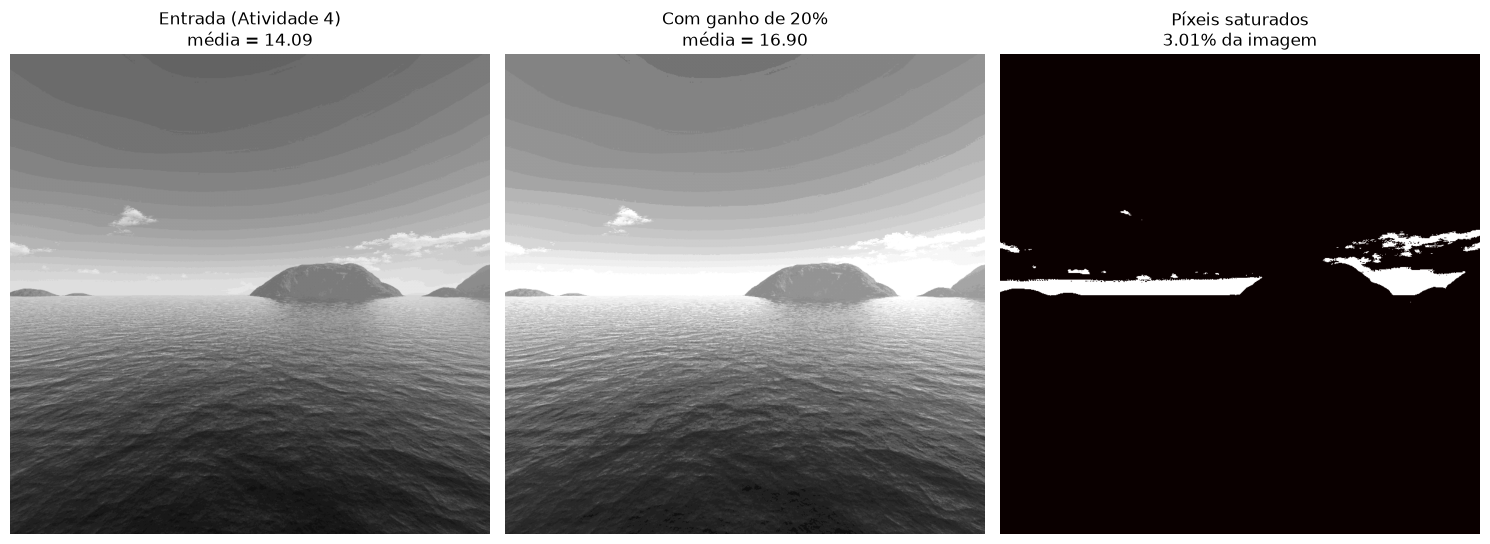

O mapa à direita marca em claro os píxeis que atingiram o teto de
31 e tiveram o ganho truncado. Concentram-se nas regiões que já
eram as mais claras da imagem original.


In [44]:
# --- Comparação visual ---

fig, eixos = plt.subplots(1, 3, figsize=(15, 5.5))

eixos[0].imshow(entrada, cmap="gray", vmin=0, vmax=MAXVAL)
eixos[0].set_title(f"Entrada (Atividade 4)\nmédia = {entrada.mean():.2f}")

eixos[1].imshow(saida, cmap="gray", vmin=0, vmax=MAXVAL)
eixos[1].set_title(f"Com ganho de {(GANHO - 1) * 100:.0f}%\nmédia = {saida.mean():.2f}")

# Mapa de saturação: onde o ganho foi truncado
mapa_sat = (np.rint(bruto_completo) > MAXVAL)
eixos[2].imshow(mapa_sat, cmap="hot", vmin=0, vmax=1)
eixos[2].set_title(f"Píxeis saturados\n{proporcao:.2f}% da imagem")

for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("O mapa à direita marca em claro os píxeis que atingiram o teto de")
print(f"{MAXVAL} e tiveram o ganho truncado. Concentram-se nas regiões que já")
print("eram as mais claras da imagem original.")

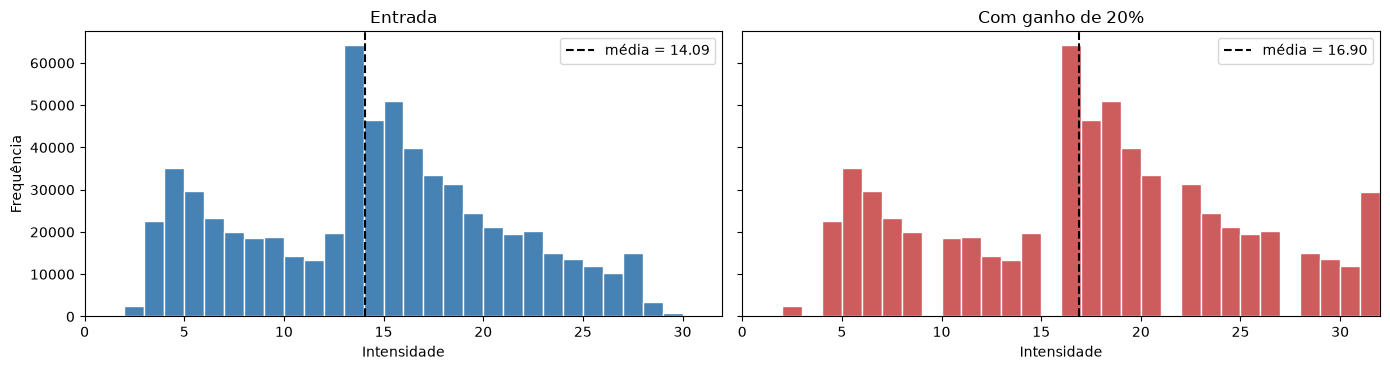

Três efeitos visíveis no histograma da saída:
  1. Deslocamento geral para a direita — é o ganho de brilho.
  2. Espalhamento maior — o ganho multiplicativo expande as diferenças.
  3. Pico acumulado no nível 31 — é a saturação: vários níveis
     de entrada empilhados em um único nível de saída.


In [45]:
# --- Histogramas: deslocamento e acúmulo no teto ---

fig, eixos = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True)

eixos[0].hist(entrada.ravel(), bins=MAXVAL + 1, range=(0, MAXVAL + 1),
              color="steelblue", edgecolor="white")
eixos[0].axvline(entrada.mean(), color="black", linestyle="--",
                 label=f"média = {entrada.mean():.2f}")
eixos[0].set_title("Entrada")
eixos[0].legend()

eixos[1].hist(saida.ravel(), bins=MAXVAL + 1, range=(0, MAXVAL + 1),
              color="indianred", edgecolor="white")
eixos[1].axvline(saida.mean(), color="black", linestyle="--",
                 label=f"média = {saida.mean():.2f}")
eixos[1].set_title(f"Com ganho de {(GANHO - 1) * 100:.0f}%")
eixos[1].legend()

for ax in eixos:
    ax.set_xlabel("Intensidade")
    ax.set_xlim(0, MAXVAL + 1)
eixos[0].set_ylabel("Frequência")
plt.tight_layout()
plt.show()

print("Três efeitos visíveis no histograma da saída:")
print(f"  1. Deslocamento geral para a direita — é o ganho de brilho.")
print(f"  2. Espalhamento maior — o ganho multiplicativo expande as diferenças.")
print(f"  3. Pico acumulado no nível {MAXVAL} — é a saturação: vários níveis")
print(f"     de entrada empilhados em um único nível de saída.")

## 3. Perda de informação: dois efeitos distintos

A contagem de níveis distintos cai da entrada para a saída, e há **duas causas
independentes** por trás disso.

### Saturação nas altas luzes

Os níveis de entrada mais altos são todos mapeados para 31. Eram valores
diferentes, viraram o mesmo valor — a distinção entre eles foi destruída.

Nenhuma operação posterior recupera isso: escurecer a imagem de volta dividindo
por 1,2 devolveria todos esses píxeis ao mesmo nível, produzindo uma região
chapada onde antes havia gradação. É o equivalente digital do céu "estourado" em
uma fotografia superexposta.

### Lacunas por arredondamento

Um efeito mais sutil: como a multiplicação por 1,2 seguida de arredondamento é
uma função de inteiros para inteiros que **não é sobrejetora**, alguns níveis de
saída simplesmente nunca são produzidos — não há nenhum nível de entrada que
resulte neles.

O histograma da saída fica com aparência de "pente", com barras vazias
intercaladas. Isso é característico de transformações pontuais aplicadas sobre
imagens de baixa profundidade de bits, e o motivo é que só existem 32 níveis de
partida para preencher 32 níveis de chegada com uma função não linear nos
inteiros.

A célula abaixo separa numericamente as duas causas.

In [46]:
# --- Diagnóstico da perda de níveis ---

niveis_entrada = set(np.unique(entrada).tolist())
niveis_saida = set(np.unique(saida).tolist())

# Níveis de saída que a LUT nunca produz (lacunas por arredondamento)
alcancaveis = set(lut.tolist())
lacunas = sorted(set(range(MAXVAL + 1)) - alcancaveis)

# Níveis de entrada que colapsaram no teto
colapsados_no_teto = sorted(int(v) for v in niveis if lut[v] == MAXVAL)

print(f"Níveis distintos na entrada : {len(niveis_entrada)}")
print(f"Níveis distintos na saída   : {len(niveis_saida)}")
print()
print(f"Lacunas por arredondamento  : {lacunas}")
print(f"  (níveis de saída que nenhum valor de entrada consegue produzir)")
print()
print(f"Colapsados no teto {MAXVAL}      : {colapsados_no_teto}")
print(f"  ({len(colapsados_no_teto)} níveis de entrada -> 1 único nível de saída)")

Níveis distintos na entrada : 29
Níveis distintos na saída   : 25

Lacunas por arredondamento  : [3, 9, 15, 21, 27]
  (níveis de saída que nenhum valor de entrada consegue produzir)

Colapsados no teto 31      : [26, 27, 28, 29, 30, 31]
  (6 níveis de entrada -> 1 único nível de saída)


## 4. Comparação: ordem das operações importa

Uma questão de projeto que vale explorar. O enunciado pede o ganho sobre a
imagem da Atividade 4 — ou seja, **quantizar primeiro, clarear depois**. Mas a
ordem inversa também seria possível: clarear a imagem original de 8 bits e só
então quantizar para 5 bits.

| Caminho | Ordem                                    |
|---------|------------------------------------------|
| **A**   | 8 bits → quantiza → 5 bits → ganho → 5 bits |
| **B**   | 8 bits → ganho → 8 bits → quantiza → 5 bits |

O caminho **A** é o pedido e é o resultado oficial. O caminho **B** serve de
comparação: ao aplicar o ganho enquanto ainda há 256 níveis disponíveis, o
arredondamento acontece uma vez só, no final, em vez de duas vezes em sequência.

O interesse aqui é constatar se a diferença é mensurável — e o que ela diz sobre
encadear operações em imagens de baixa profundidade.

*Esta seção requer o arquivo original de 8 bits da Atividade 4. Se ele não
estiver disponível, a célula é ignorada sem erro.*

                               caminho A   caminho B
----------------------------------------------------
Média                             16.902      16.865
Desvio padrão                      7.610       7.638
Níveis distintos                      25          30

Píxeis com resultado diferente: 178,638 (27.91%)
Diferença máxima entre os caminhos: 1 nível(is)


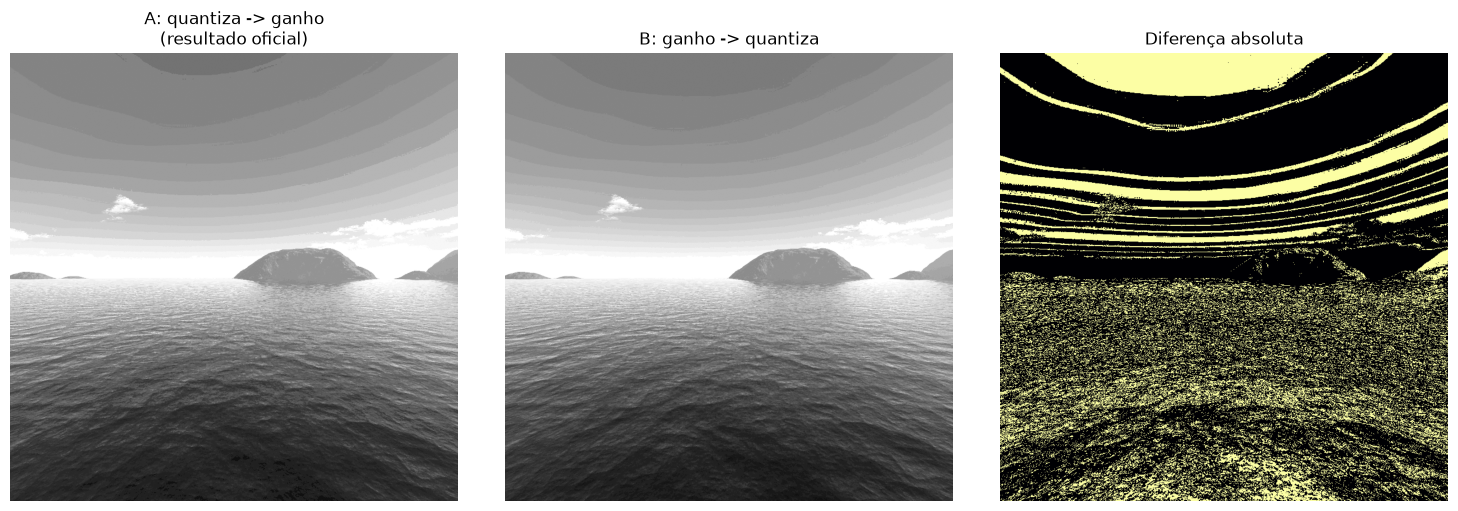

In [47]:
# --- Caminho B: ganho antes da quantização (comparação) ---

ARQUIVO_8BITS = ENTRADA / "EntradaEscalaCinza.pgm"

if ARQUIVO_8BITS.exists():
    original8, maxval8 = ler_pgm_p2(ARQUIVO_8BITS)

    # B: ganho em 8 bits, depois quantização para 5 bits
    com_ganho8 = np.clip(np.rint(original8 * GANHO), 0, maxval8)
    caminho_b = np.clip(np.rint(com_ganho8 * MAXVAL / maxval8), 0, MAXVAL).astype(np.int32)

    caminho_a = saida
    divergentes = int((caminho_a != caminho_b).sum())

    print(f"{'':<28}{'caminho A':>12}{'caminho B':>12}")
    print("-" * 52)
    print(f"{'Média':<28}{caminho_a.mean():>12.3f}{caminho_b.mean():>12.3f}")
    print(f"{'Desvio padrão':<28}{caminho_a.std():>12.3f}{caminho_b.std():>12.3f}")
    print(f"{'Níveis distintos':<28}{np.unique(caminho_a).size:>12}"
          f"{np.unique(caminho_b).size:>12}")
    print()
    print(f"Píxeis com resultado diferente: {divergentes:,} "
          f"({divergentes / caminho_a.size * 100:.2f}%)")
    print(f"Diferença máxima entre os caminhos: "
          f"{int(np.abs(caminho_a - caminho_b).max())} nível(is)")

    fig, eixos = plt.subplots(1, 3, figsize=(15, 5))
    eixos[0].imshow(caminho_a, cmap="gray", vmin=0, vmax=MAXVAL)
    eixos[0].set_title("A: quantiza -> ganho\n(resultado oficial)")
    eixos[1].imshow(caminho_b, cmap="gray", vmin=0, vmax=MAXVAL)
    eixos[1].set_title("B: ganho -> quantiza")
    eixos[2].imshow(np.abs(caminho_a - caminho_b), cmap="inferno")
    eixos[2].set_title("Diferença absoluta")
    for ax in eixos:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"Arquivo {ARQUIVO_8BITS.name} não encontrado — comparação ignorada.")

  ganho     média   % saturado   níveis
----------------------------------------
    1.0    14.091        0.00%       29
    1.2    16.902        3.01%       25
    1.5    20.332       17.18%       20
    2.0    24.288       40.67%       15
    3.0    27.214       71.13%       10
    5.0    29.436       82.32%        6


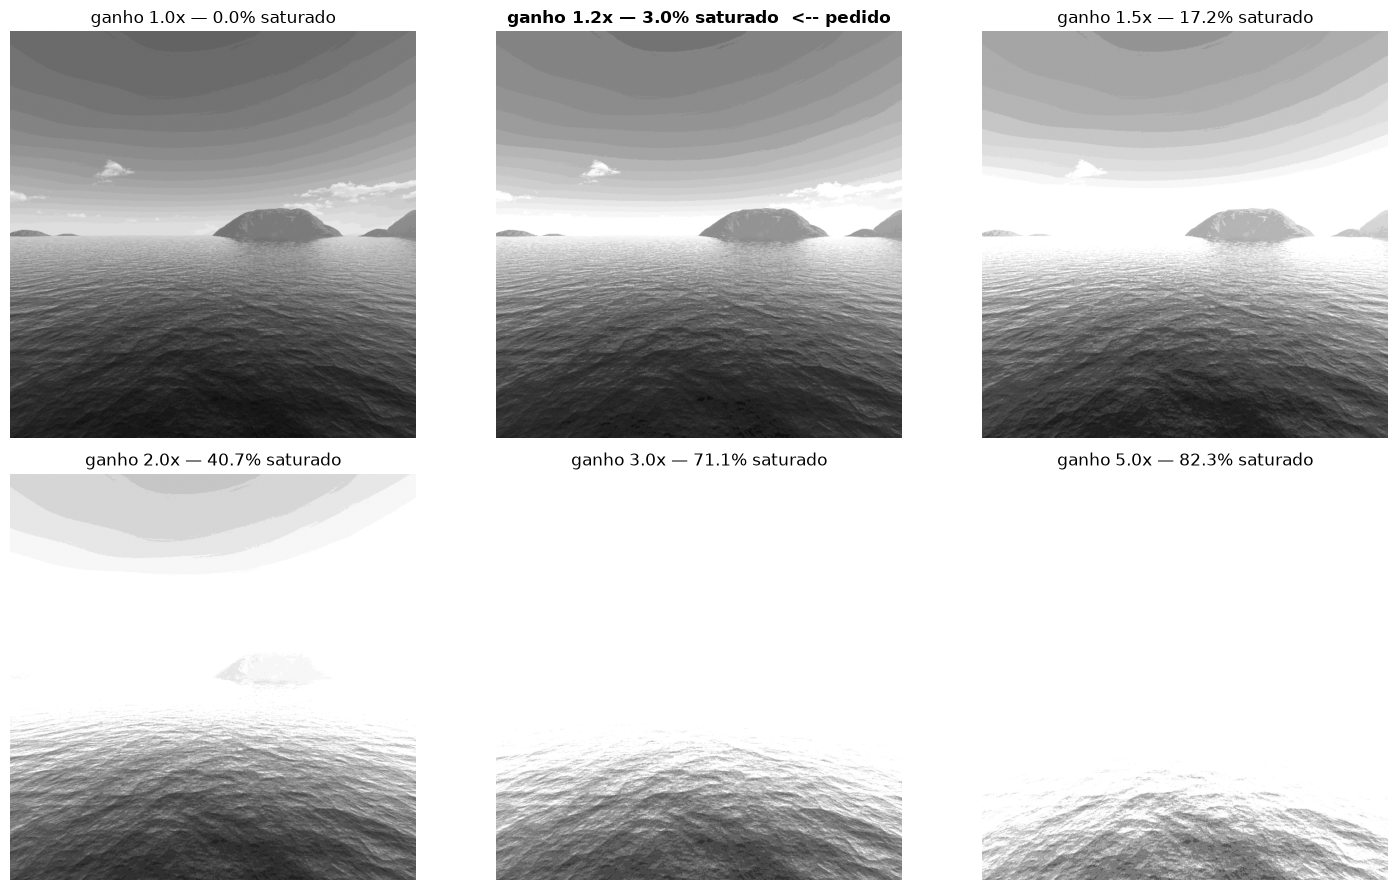


A progressão mostra por que 1,2 é um ganho conservador: a saturação
cresce rapidamente com o fator, e a partir de certo ponto a imagem
perde estrutura, convergindo para uma mancha branca uniforme.


In [48]:
# --- Bônus: varredura de fatores de ganho ---

fatores = [1.0, 1.2, 1.5, 2.0, 3.0, 5.0]
fig, eixos = plt.subplots(2, 3, figsize=(15, 9))

print(f"{'ganho':>7}{'média':>10}{'% saturado':>13}{'níveis':>9}")
print("-" * 40)

for ax, g in zip(eixos.ravel(), fatores):
    r = aplicar_ganho(entrada, ganho=g)
    sat = (np.rint(entrada * g) > MAXVAL).mean() * 100

    ax.imshow(r, cmap="gray", vmin=0, vmax=MAXVAL)
    destaque = "  <-- pedido" if g == GANHO else ""
    ax.set_title(f"ganho {g}x — {sat:.1f}% saturado{destaque}",
                 fontweight="bold" if g == GANHO else "normal")
    ax.axis("off")

    print(f"{g:>7.1f}{r.mean():>10.3f}{sat:>12.2f}%{np.unique(r).size:>9}")

plt.tight_layout()
plt.show()

print()
print("A progressão mostra por que 1,2 é um ganho conservador: a saturação")
print("cresce rapidamente com o fator, e a partir de certo ponto a imagem")
print("perde estrutura, convergindo para uma mancha branca uniforme.")

---

## 5. Conclusões

### Resultado

O ganho de 20% foi aplicado à imagem de 5 bits produzida na Atividade 4, com
saturação em `maxval = 31`, e gravado em
`saida/SaidaEscalaCinza_5bits_brilho120.pgm` — PGM P2 válido, verificado por
round-trip e pelo limite de 70 colunas.

### O que a saturação custou

Cerca de 3% dos píxeis atingiram o teto e tiveram o ganho truncado. Como
consequência, o aumento efetivo do brilho médio ficou ligeiramente abaixo dos
20% nominais: os píxeis mais claros não puderam receber o ganho integral.

Essa perda é irreversível. Vários níveis de entrada distintos foram mapeados
para o mesmo valor 31, e dividir a imagem por 1,2 não os separaria de volta —
produziria apenas uma região chapada onde antes havia gradação.

### Por que o efeito é mais severo em 5 bits

Trabalhar com apenas 32 níveis torna a operação bem mais destrutiva do que seria
sobre a original de 8 bits. Dois motivos:

- A **margem até o teto** é proporcionalmente a mesma, mas cada nível saturado
  representa uma fatia maior da informação disponível.
- O **arredondamento** sobre poucos níveis abre lacunas visíveis no histograma —
  níveis de saída que nenhum valor de entrada consegue produzir. Com 256 níveis
  esse efeito existe, mas é imperceptível.

A comparação entre os dois caminhos reforça o ponto geral: **encadear operações
sobre imagens de baixa profundidade acumula erro de arredondamento**. Sempre que
o fluxo de trabalho permitir, convém realizar as transformações na maior
profundidade disponível e quantizar apenas ao final — a mesma recomendação que a
apostila faz a respeito de redimensionar imagens JFIF, onde reduzir dimensões
depois de uma compressão com perda significativa "resulta em imagens de muito má
qualidade porque a informação necessária ao processo é insuficiente".

### Verificações realizadas

1. Cálculo direto e aplicação via LUT produzem resultados idênticos — confirma
   que a transformação é genuinamente pontual.
2. Todos os valores da saída pertencem a `[0, 31]` — arquivo semanticamente
   válido para o `maxval` declarado.
3. Round-trip de escrita e leitura sem divergências.
4. Nenhuma linha do arquivo excede 70 caracteres.